# White Box - Supervised ML Project
__Name:__ Ali Hasan

__Topic Name:__ Regression Topic 

## Introduction
The gaming industry has grown exponentially over the years, with video game sales being a key indicator of success. This project aims to develop machine learning models that can predict global video game sales based on various features such as platform, genre, publisher, and regional sales data.

### Problem Statement
Develop a machine learning model to predict global video game sales based on features like platform, genre, publisher, and regional sales data.


### Objectives
List the key questions guiding your analysis and modeling:
- What features influence the target variable?
- Can feature engineering improve model performance?
- How do different model versions compare?
- Identify which features most influence game sales
- Build and evaluate a KNN regression model
- Find the optimal k value for best performance
- Assess model accuracy in predicting sales

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

## Data Overview
__Load and inspect the dataset__
- Source and format
- .head(), .info(), .describe(),…


In [3]:
df = pd.read_csv('vgsales.csv')
print("Dataset Shape:", df.shape)


Dataset Shape: (16598, 11)


In [4]:
print("Dataset head:")
df.head()

Dataset head:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [5]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [6]:
print("Descriptive Statistics:")
df.describe(include='all')

Descriptive Statistics:


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16598,16598,16327.000000,16598,16540,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
unique,NaN,11493,31,NaN,12,578,NaN,NaN,NaN,NaN,NaN
top,NaN,Need for Speed: Most Wanted,DS,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN
freq,NaN,12,2163,NaN,3316,1351,NaN,NaN,NaN,NaN,NaN
mean,8300.605254,NaN,NaN,2006.406443,NaN,NaN,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,NaN,NaN,5.828981,NaN,NaN,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,NaN,NaN,1980.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,NaN,NaN,2003.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,NaN,NaN,2007.000000,NaN,NaN,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,NaN,NaN,2010.000000,NaN,NaN,0.240000,0.110000,0.040000,0.040000,0.470000


In [7]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

## Data Cleaning
__Handle missing values, outliers, and inconsistencies__
- Rename columns
- Fix data types
- Document assumptions


In [8]:
df_clean = df.copy()

In [9]:
print(f"\nDuplicate rows: {df_clean.duplicated().sum()}")


Duplicate rows: 0


In [10]:
missing_percent = (df_clean.isnull().sum() / len(df_clean)) * 100
missing_percent

Rank            0.000000
Name            0.000000
Platform        0.000000
Year            1.632727
Genre           0.000000
Publisher       0.349440
NA_Sales        0.000000
EU_Sales        0.000000
JP_Sales        0.000000
Other_Sales     0.000000
Global_Sales    0.000000
dtype: float64

In [11]:
# For Year: Since it's only 1.6% missing, we can drop these rows
df_clean = df_clean.dropna(subset=['Year'])

# For Publisher: We'll fill with 'Unknown'
df_clean['Publisher'] = df_clean['Publisher'].fillna('Unknown')


In [12]:
# Convert Year to integer
df_clean['Year'] = df_clean['Year'].astype(int)

## Exploratory Data Analysis (EDA)
### Analysis
__Answer objectives using visual and statistical insights__
- Trends, relationships, anomalies
- Outlier and missing values treatment
- Univariate, bivariate, or multivariate analysis
    - Histograms, box plots, bar charts
    - Correlation matrix for continuous columns (required if applicable)


count    16327.000000
mean         0.540232
std          1.565732
min          0.010000
25%          0.060000
50%          0.170000
75%          0.480000
max         82.740000
Name: Global_Sales, dtype: float64


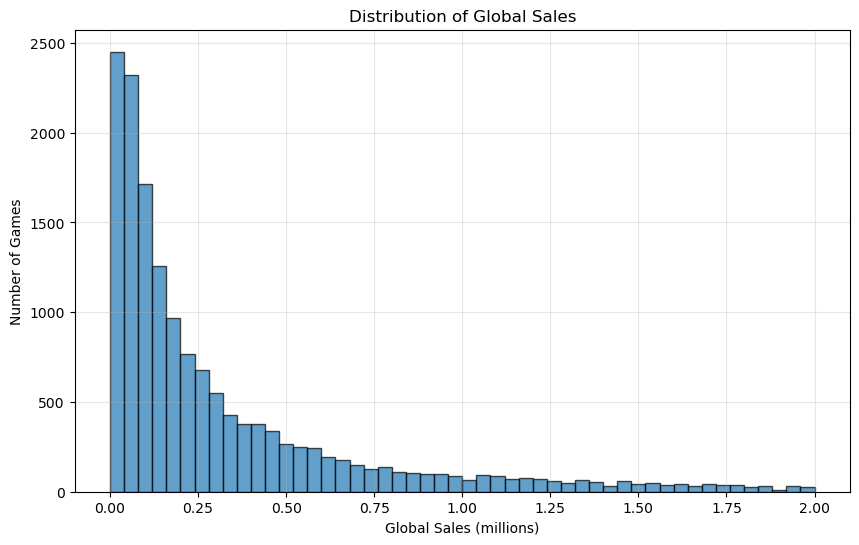

In [13]:
#Target column:

print(df_clean['Global_Sales'].describe())

# Show the distribution
plt.figure(figsize=(10, 6))
plt.hist(df_clean['Global_Sales'], bins=50, alpha=0.7, edgecolor='black',range=(0,2))
plt.title('Distribution of Global Sales')
plt.xlabel('Global Sales (millions)')
plt.ylabel('Number of Games')
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
print("\n=== TOP SELLING GAMES ===")
top_10_games = df_clean.nlargest(10, 'Global_Sales')[['Name', 'Platform', 'Year', 'Genre', 'Global_Sales']]
print(top_10_games)

print("\n=== WHAT MAKES GAMES SUCCESSFUL? ===")

# By Platform
print("\nTop Platforms by Average Sales:")
platform_avg = df_clean.groupby('Platform')['Global_Sales'].mean().sort_values(ascending=False).head(10)
print(platform_avg.round(2))

# By Genre
print("\nGenres by Average Sales:")
genre_avg = df_clean.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)
print(genre_avg.round(2))


=== TOP SELLING GAMES ===
                        Name Platform  Year         Genre  Global_Sales
0                 Wii Sports      Wii  2006        Sports         82.74
1          Super Mario Bros.      NES  1985      Platform         40.24
2             Mario Kart Wii      Wii  2008        Racing         35.82
3          Wii Sports Resort      Wii  2009        Sports         33.00
4   Pokemon Red/Pokemon Blue       GB  1996  Role-Playing         31.37
5                     Tetris       GB  1989        Puzzle         30.26
6      New Super Mario Bros.       DS  2006      Platform         30.01
7                   Wii Play      Wii  2006          Misc         29.02
8  New Super Mario Bros. Wii      Wii  2009      Platform         28.62
9                  Duck Hunt      NES  1984       Shooter         28.31

=== WHAT MAKES GAMES SUCCESSFUL? ===

Top Platforms by Average Sales:
Platform
GB      2.62
NES     2.56
GEN     1.05
SNES    0.84
PS4     0.83
X360    0.79
2600    0.75
PS3     0.

In [15]:
print("\n=== TRENDS OVER TIME ===")

# Yearly trends
yearly_stats = df_clean.groupby('Year').agg({
    'Global_Sales': ['sum', 'mean', 'count']
}).round(2)

yearly_stats.columns = ['Total_Sales', 'Average_Sales', 'Games_Released']
print("Yearly summary (last 7 years):")
print(yearly_stats.tail(7))


=== TRENDS OVER TIME ===
Yearly summary (last 7 years):
      Total_Sales  Average_Sales  Games_Released
Year                                            
2012       363.54           0.55             657
2013       368.11           0.67             546
2014       337.05           0.58             582
2015       264.44           0.43             614
2016        70.93           0.21             344
2017         0.05           0.02               3
2020         0.29           0.29               1


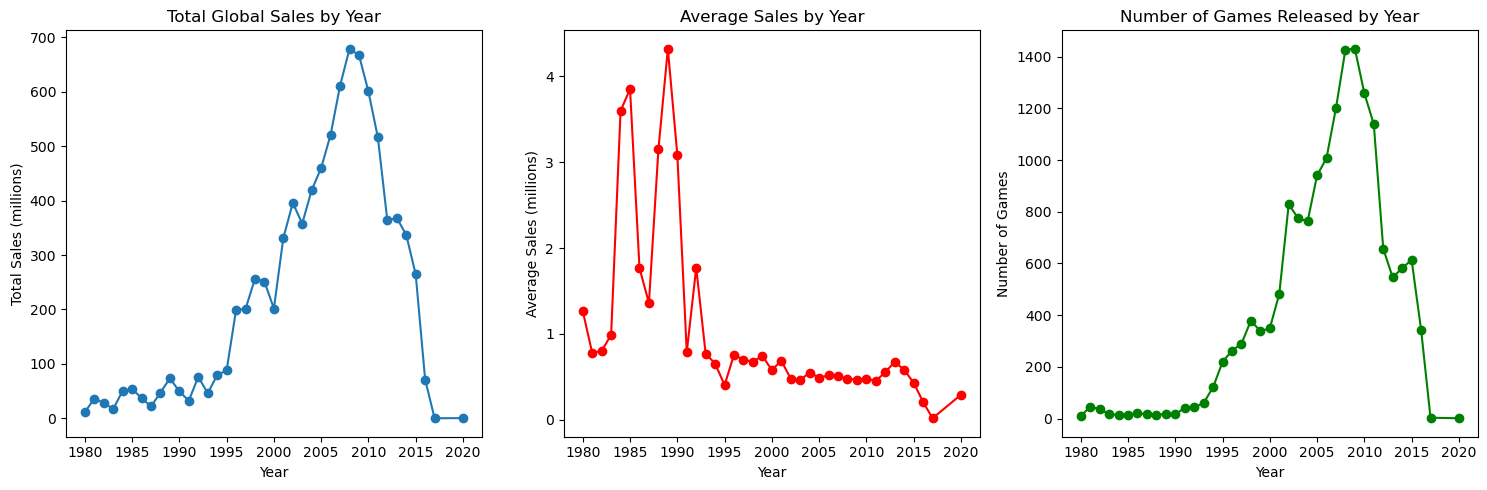

In [16]:

plt.figure(figsize=(15, 5))

# Total sales by year
plt.subplot(1, 3, 1)
yearly_total = df_clean.groupby('Year')['Global_Sales'].sum()
plt.plot(yearly_total.index, yearly_total.values, marker='o')
plt.title('Total Global Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales (millions)')


# Average sales by year
plt.subplot(1, 3, 2)
yearly_avg = df_clean.groupby('Year')['Global_Sales'].mean()
plt.plot(yearly_avg.index, yearly_avg.values, marker='o', color='red')
plt.title('Average Sales by Year')
plt.xlabel('Year')
plt.ylabel('Average Sales (millions)')


# Number of games by year
plt.subplot(1, 3, 3)
games_per_year = df_clean['Year'].value_counts().sort_index()
plt.plot(games_per_year.index, games_per_year.values, marker='o', color='green')
plt.title('Number of Games Released by Year')
plt.xlabel('Year')
plt.ylabel('Number of Games')


plt.tight_layout()
plt.show()

The year we have the most global sales it's the same year as we have the most game released (~2009)
but the most average sales year is 1988

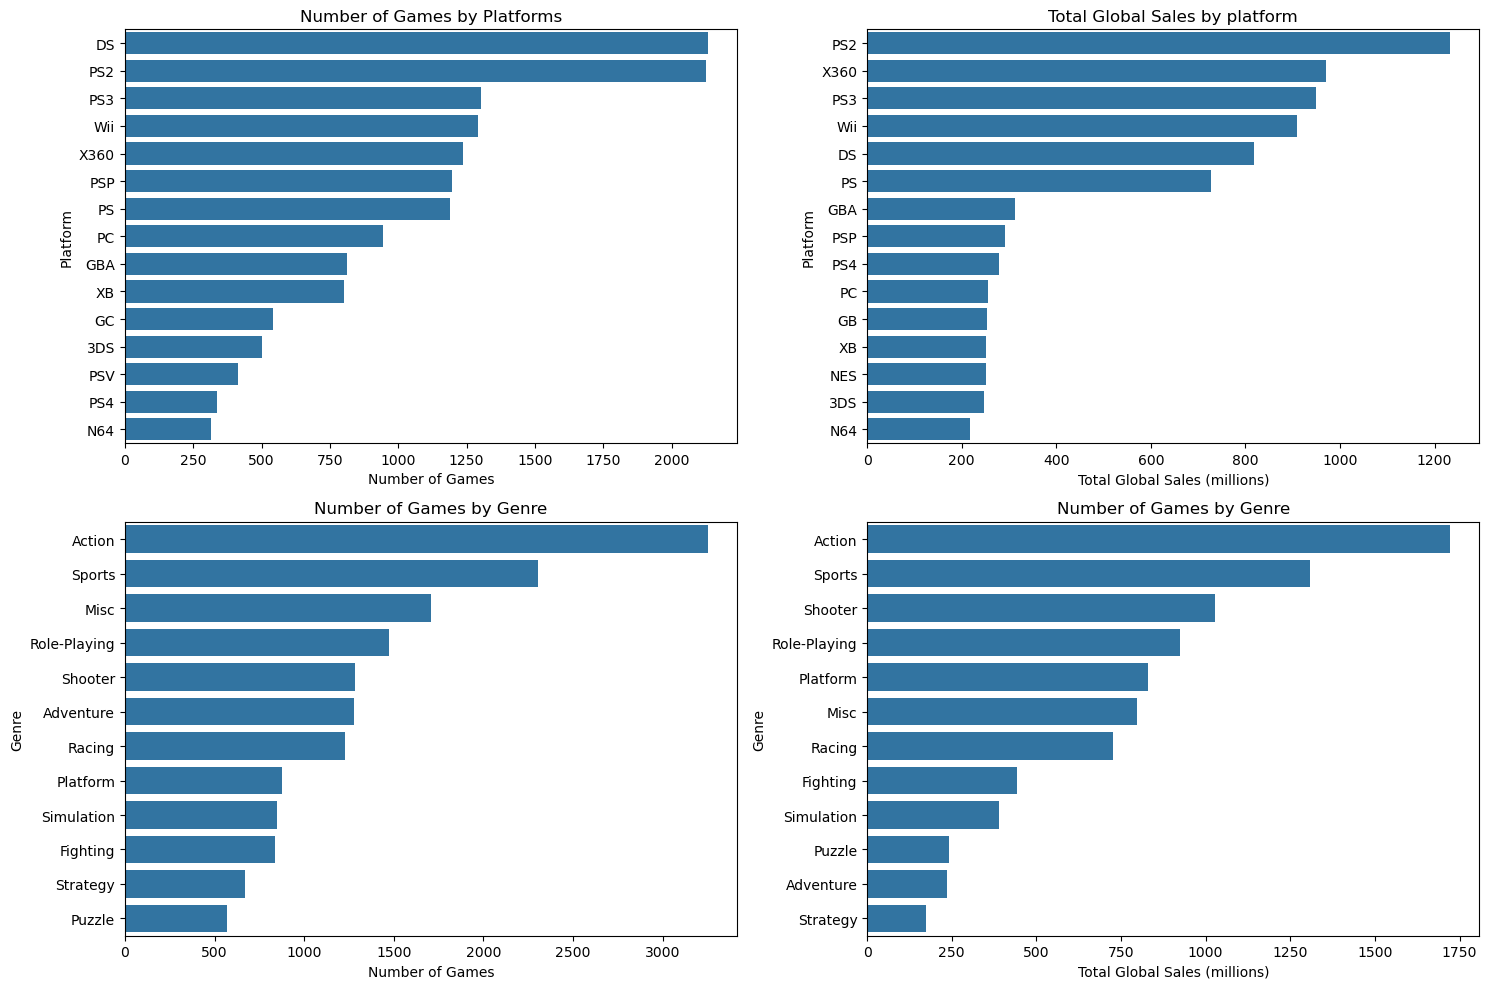

In [17]:
# Platform analysis
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
platform_counts = df_clean['Platform'].value_counts().head(15)
sns.barplot(x=platform_counts.values, y=platform_counts.index)
plt.title('Number of Games by Platforms')
plt.xlabel('Number of Games')

plt.subplot(2, 2, 2)
platform_sales = df_clean.groupby('Platform')['Global_Sales'].sum().nlargest(15)
sns.barplot(x=platform_sales.values, y=platform_sales.index)
plt.title('Total Global Sales by platform')
plt.xlabel('Total Global Sales (millions)')

plt.subplot(2, 2, 3)
genre_counts = df_clean['Genre'].value_counts()
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Number of Games by Genre')
plt.xlabel('Number of Games')

plt.subplot(2, 2, 4)
genre_sales = df_clean.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
sns.barplot(x=genre_sales.values, y=genre_sales.index)
plt.title('Number of Games by Genre')
plt.xlabel('Total Global Sales (millions)')

plt.tight_layout()
plt.show()

## Model Building
__Build and compare two models for your topic__
### Model 1: Linear / Logistic Regression
- Version 1: baseline
- Version 2: modified features or tuned parameters
- Checking if model assumptions were met
 ...


In [18]:
df_clean.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [29]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

X = df_clean[['Platform','Genre','Publisher']]
y = df_clean['Global_Sales']

X = pd.get_dummies( drop_first=True, data=X)





In [30]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=50
)

logreg = LinearRegression()
logreg.fit(X_train, y_train)


print("Intercept:", logreg.intercept_)
print("Coefficients:", logreg.coef_)

Intercept: 0.47937673809979575
Coefficients: [-3.07879275e-01 -4.07779688e-01 -3.43835999e-01 -3.06874590e-01
  7.31733690e-01 -5.49713247e-01 -6.35279397e-01  1.71286528e-01
 -9.25268854e-01 -4.20334157e-01  1.15993733e+00 -2.93696855e-01
 -4.53458740e-01 -5.13269716e+10 -7.65236567e-02 -7.50163413e-02
  2.34029087e-02  5.72988954e-02 -3.29235333e-01 -3.40399658e-01
 -3.86224797e-01 -5.53211265e-01  2.32123631e-01 -5.13269716e+10
 -2.33555180e-01 -1.37892640e-02 -7.94400797e-01  8.96307301e-03
 -5.54896454e-01 -2.39621177e-01 -1.87727071e-01  9.69643101e-02
 -1.46871579e-01  2.61112275e-01 -2.26776353e-01  1.69734280e-02
  6.51625287e-02  2.04337152e-01 -6.96861700e-03 -5.31412307e-02
 -2.26142803e-01  6.25502693e-02 -1.27140255e-01  2.21832494e-01
 -7.42194556e-02  4.13753496e+12 -6.87544075e-02 -1.60396967e-01
 -2.36837516e-01 -1.03672585e+12  7.00509168e-01 -1.36396910e-01
  2.84425259e-01  1.30195762e-01 -1.73149157e-02  9.12238611e-02
 -4.39619148e-01  1.39667421e-01 -3.02069134e

In [31]:
from sklearn.metrics import r2_score, mean_squared_error
y_pred = logreg.predict(X_test)

print("R2 (test):", r2_score(y_test, y_pred))
print("RMSE (test):", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 (test): -3.91849674732557e+24
RMSE (test): 2531693535206.2925


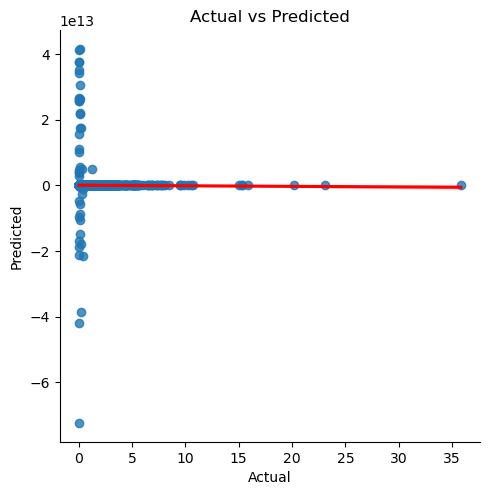

In [32]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

# Plot
sns.lmplot(
    x='Actual',
    y='Predicted',
    data=results,
    line_kws={'color': 'red'}
)

plt.title('Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()


In [33]:
X = df_clean[['Platform']]
y = df_clean['Global_Sales']

X = pd.get_dummies( drop_first=True, data=X)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, random_state=50
)

logreg2 = LinearRegression()
logreg2.fit(X_train2, y_train2)


print("Intercept:", logreg.intercept_)
print("Coefficients:", logreg.coef_)

Intercept: 0.47937673809979575
Coefficients: [-3.07879275e-01 -4.07779688e-01 -3.43835999e-01 -3.06874590e-01
  7.31733690e-01 -5.49713247e-01 -6.35279397e-01  1.71286528e-01
 -9.25268854e-01 -4.20334157e-01  1.15993733e+00 -2.93696855e-01
 -4.53458740e-01 -5.13269716e+10 -7.65236567e-02 -7.50163413e-02
  2.34029087e-02  5.72988954e-02 -3.29235333e-01 -3.40399658e-01
 -3.86224797e-01 -5.53211265e-01  2.32123631e-01 -5.13269716e+10
 -2.33555180e-01 -1.37892640e-02 -7.94400797e-01  8.96307301e-03
 -5.54896454e-01 -2.39621177e-01 -1.87727071e-01  9.69643101e-02
 -1.46871579e-01  2.61112275e-01 -2.26776353e-01  1.69734280e-02
  6.51625287e-02  2.04337152e-01 -6.96861700e-03 -5.31412307e-02
 -2.26142803e-01  6.25502693e-02 -1.27140255e-01  2.21832494e-01
 -7.42194556e-02  4.13753496e+12 -6.87544075e-02 -1.60396967e-01
 -2.36837516e-01 -1.03672585e+12  7.00509168e-01 -1.36396910e-01
  2.84425259e-01  1.30195762e-01 -1.73149157e-02  9.12238611e-02
 -4.39619148e-01  1.39667421e-01 -3.02069134e

In [34]:
y_pred2 = logreg.predict(X_test)

print("R2 (test):", r2_score(y_test2, y_pred2))
print("RMSE (test):", np.sqrt(mean_squared_error(y_test2, y_pred2)))

R2 (test): -3.91849674732557e+24
RMSE (test): 2531693535206.2925


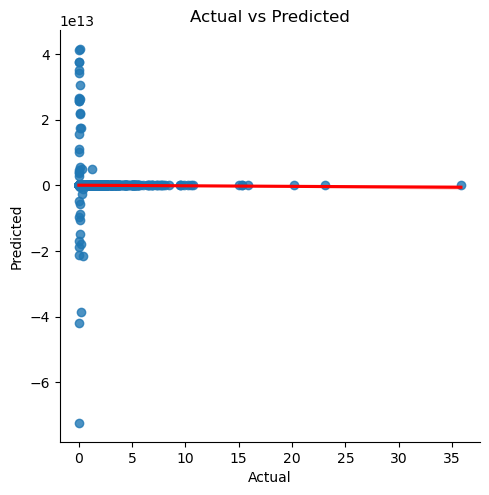

In [35]:
results2 = pd.DataFrame({
    'Actual': y_test2,
    'Predicted': y_pred2
})

# Plot
sns.lmplot(
    x='Actual',
    y='Predicted',
    data=results2,
    line_kws={'color': 'red'}
)

plt.title('Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()


### Model 2: KNN Regressor / KNN Classifier
- Version 1: baseline
- Version 2: modified features or tuned parameters
- Checking if model assumptions were met 
 ...


In [36]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


In [37]:
knn_base = KNeighborsRegressor(n_neighbors=5)
knn_base.fit(X_train, y_train)
y_pred_base = knn_base.predict(X_test)
print("Baseline R²:", r2_score(y_test, y_pred_base))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_base)))


knn_tuned = KNeighborsRegressor(n_neighbors=31, weights='distance')
knn_tuned.fit(X_train, y_train)
y_pred_tuned = knn_tuned.predict(X_test)
print("Tuned R²:", r2_score(y_test, y_pred_tuned))
print("Tuned RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned)))

Baseline R²: -0.024277407423302977
Baseline RMSE: 1.2943752022250843
Tuned R²: 0.04853000850964917
Tuned RMSE: 1.2475240738940314


### Model Evaluation
__Use appropriate metrics based on task type and compare between the Models and their versions__

__For Regression:__
- R² Score
- Root Mean Squared Error (RMSE)
- Residual plots


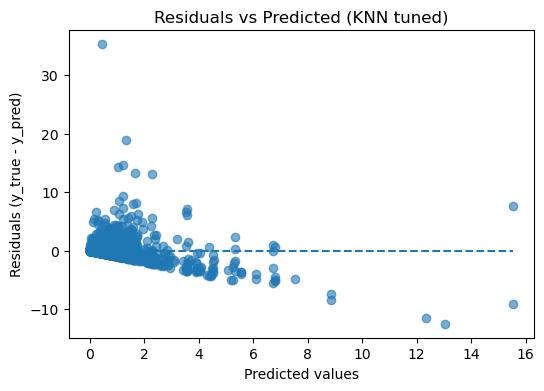

In [38]:
residuals = y_test - y_pred_tuned
plt.figure(figsize=(6,4))
plt.scatter(y_pred_tuned, residuals, alpha=0.6)
plt.hlines(0, xmin=min(y_pred_tuned), xmax=max(y_pred_tuned), linestyles='dashed')
plt.xlabel("Predicted values")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("Residuals vs Predicted (KNN tuned)")
plt.show()

__For Classification:__
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC _**(Optional)**_
- Confusion Matrix

_Include visualizations and interpretation for each metric._


### Model Comparison
__Compare performance across models and versions__

__Note:__ _Use Bullet Points or table_
- Which model performed best and why
- Impact of feature changes or tuning
- Generalization and overfitting observations


The tuned KNN (n_neighbors=31, weights='distance') performed best, achieving higher R² and lower errors.

More feature not necessary will cause better results

## Final Model & Insights
__Summarize your final model and key takeaways__

__Note__: _Use Bullet Points_
- Final model choice
- Business implications
- Limitations and future improvements


Final Model Choice:

KNeighborsRegressor(n_neighbors=31, weights='distance'), the results is very bad because we have only categorical feature

## References & Appendix
__Cite tools, libraries, and sources used__